# Equidistant grid convergence test

After building ``RAPID``, the executable binary ``simulation`` is located in the bin folder.


In [1]:
import subprocess
import os

# ensure we run from project root if notebook is inside "notebooks"
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    os.chdir("..")

yaml_files = [
    "notebooks/configs/convergence_test_128.yaml",
    "notebooks/configs/convergence_test_256.yaml",
    "notebooks/configs/convergence_test_512.yaml",
    "notebooks/configs/convergence_test_1024.yaml",
    "notebooks/configs/convergence_test_2048.yaml",
    "notebooks/configs/convergence_test_4096.yaml"
]

for yaml_path in yaml_files:
    print("\n==============================================")
    print(f"Running simulation for: {yaml_path}")
    print("==============================================\n")

    cmd = [
        "python3",
        "run_simulation.py",
        "--config",
        yaml_path
    ]

    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

    for line in process.stdout:
        print(line.rstrip("\n"))

    process.wait()

    print(f"\nSimulation finished for: {yaml_path}\n")



Running simulation for: notebooks/configs/convergence_test_128.yaml

[PY-WRAPPER] Terminal panels disabled (YAML setting).

[PY-WRAPPER] --- Running: Main Simulation Program ---
[PY-WRAPPER] The current command-line arguments are:
 ./bin/simulation -v -no_panels -evol 1.0 -test ring_viscosity -n 128 -ri 1.0 -ro 50.0 -disk_mass 0.01 -alpha_init 0.01 -stellar_mass 1.0 -inner_bc parabolic -outer_bc reflecting -o notebooks/convergence_test/convergence_128 -tmax 1 -outfreq 1
[PY-WRAPPER] Setting OMP_NUM_THREADS=1 for this run.
[PY-WRAPPER] Start running the binary (./bin/simulation) at 2026-09-23 20:12:16...

||                                                                      ||
||                        RAPID SIMULATION CORE                         ||
||                            Version: 2.2.4                            ||
||                                                                      ||
||                  Lead Developer: [D. Tarczay-Nehez]                  ||
||          

## Calculate numerical convergence

N=128: weighted relative L1 error = 4.690170e-02
N=256: weighted relative L1 error = 1.176120e-02
N=512: weighted relative L1 error = 2.971471e-03
N=1024: weighted relative L1 error = 7.610651e-04
N=2048: weighted relative L1 error = 1.804161e-04
Measured convergence slope: -1.9994


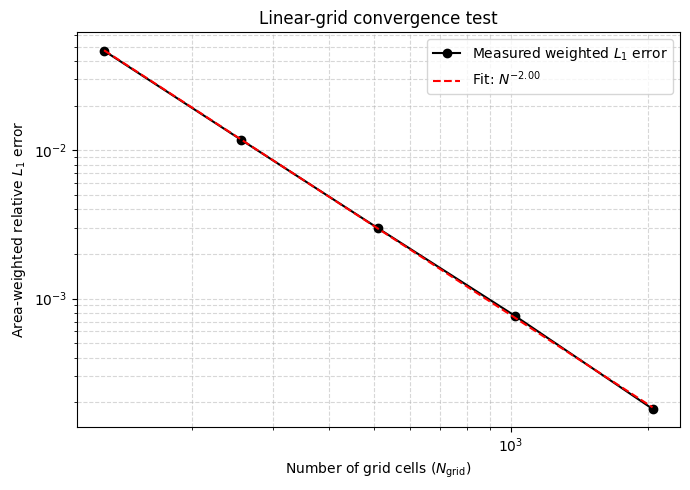

Saved: /Users/tnehezd/Documents/Munka/dust_drift/notebooks/ring_linear_convergence.png


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def find_project_root():
    """Find the repository root from the notebook's current working directory."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "run_simulation.py").exists() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the RAPID project root.")


project_root = find_project_root()
results_root = project_root / "notebooks" / "convergence_test"
reference_n = 4096
resolutions = [128, 256, 512, 1024, 2048]


def load_profile(n):
    path = results_root / f"convergence_{n}" / "LOGS" / "ring_profile_t_000000.dat"
    if not path.exists():
        raise FileNotFoundError(path)

    data = np.loadtxt(path)
    radius = data[:, 0]
    sigma = data[:, 1]
    order = np.argsort(radius)
    radius = radius[order]
    sigma = sigma[order]

    if np.any(np.diff(radius) <= 0.0):
        raise ValueError(f"Radius is not strictly increasing: {path}")
    return radius, sigma


def annulus_weights(radius):
    edges = np.empty(radius.size + 1)
    edges[1:-1] = 0.5 * (radius[:-1] + radius[1:])
    edges[0] = radius[0] - 0.5 * (radius[1] - radius[0])
    edges[-1] = radius[-1] + 0.5 * (radius[-1] - radius[-2])
    return np.pi * (edges[1:] ** 2 - edges[:-1] ** 2)


r_ref, sigma_ref = load_profile(reference_n)
reference_weights = annulus_weights(r_ref)
errors = []
valid_resolutions = []

for n in resolutions:
    try:
        radius, sigma = load_profile(n)
    except (FileNotFoundError, ValueError) as exc:
        print(f"Skipping N={n}: {exc}")
        continue

    mask = (r_ref >= radius[0]) & (r_ref <= radius[-1])
    common_radius = r_ref[mask]
    reference_values = sigma_ref[mask]
    interpolated_values = np.interp(common_radius, radius, sigma)
    weights = reference_weights[mask]

    denominator = np.sum(np.abs(reference_values) * weights)
    numerator = np.sum(np.abs(interpolated_values - reference_values) * weights)
    if denominator <= 0.0:
        raise ValueError("Reference profile has zero weighted norm.")

    valid_resolutions.append(n)
    errors.append(numerator / denominator)
    print(f"N={n}: weighted relative L1 error = {errors[-1]:.6e}")

if not errors:
    raise RuntimeError("No convergence profiles were found.")

fig, axis = plt.subplots(figsize=(7, 5))
axis.loglog(valid_resolutions, errors, "ko-", label="Measured weighted $L_1$ error")

if len(errors) >= 2 and all(error > 0.0 for error in errors):
    fit_slope, fit_intercept = np.polyfit(
        np.log(valid_resolutions), np.log(errors), 1
    )
    fitted = np.exp(fit_intercept) * np.asarray(valid_resolutions) ** fit_slope
    axis.loglog(
        valid_resolutions,
        fitted,
        "r--",
        label=fr"Fit: $N^{{{fit_slope:.2f}}}$",
    )
    print(f"Measured convergence slope: {fit_slope:.4f}")

axis.set_xlabel(r"Number of grid cells ($N_{\rm grid}$)")
axis.set_ylabel(r"Area-weighted relative $L_1$ error")
axis.set_title("Linear-grid convergence test")
axis.grid(True, which="both", linestyle="--", alpha=0.5)
axis.legend()
fig.tight_layout()

output_path = project_root / "notebooks" / "ring_linear_convergence.png"
output_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")